# Tips Prediction in Restaurant

In [25]:
from statistics import linear_regression

import numpy as np
# Import necessary libraries
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

# sci-kit learn imports.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder , StandardScaler

## 1. Load the Dataset

In [2]:
# load the data.
df = pd.read_csv('.\\datasets\\tips.csv')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 2. Data Overview

In [3]:
# Check basic information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    str    
 3   smoker      244 non-null    str    
 4   day         244 non-null    str    
 5   time        244 non-null    str    
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 13.5 KB


In [4]:
# statistical summary of the dataset.
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [5]:
# check for missing Values.
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

## 3. Data Visualization

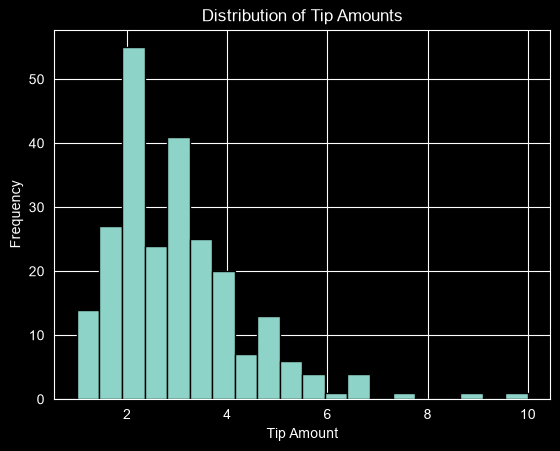

In [6]:
# Plot distribution of tip amounts
plt.hist(df['tip'], bins=20, edgecolor='black')
plt.xlabel('Tip Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Tip Amounts')
plt.show()

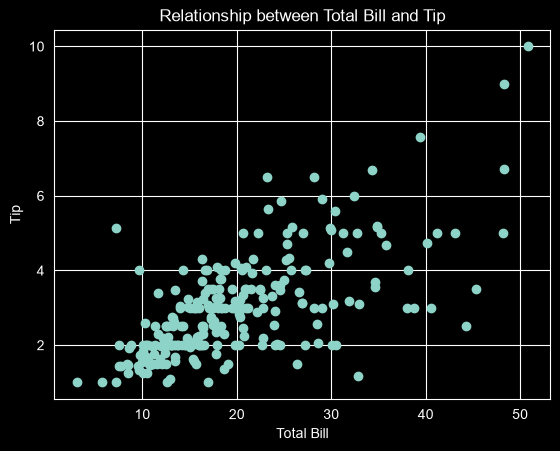

In [7]:
# Relationship between total bill and tip
plt.scatter(df['total_bill'], df['tip'])
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Relationship between Total Bill and Tip')
plt.show()

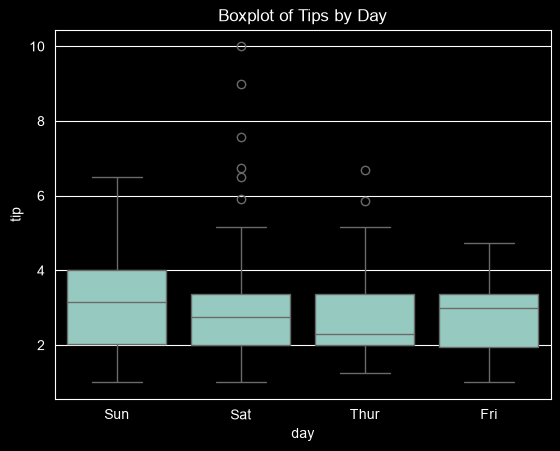

In [8]:
# Boxplot for tips by day
sns.boxplot(x='day', y='tip', data=df)
plt.title("Boxplot of Tips by Day")
plt.show()

## 4. Data Preprocessing

In [12]:
# Encode categorical variables
le = LabelEncoder()

for col in df.select_dtypes(include=['str']).columns:
    df[col] = le.fit_transform(df[col])


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    int64  
 3   smoker      244 non-null    int64  
 4   day         244 non-null    int64  
 5   time        244 non-null    int64  
 6   size        244 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 13.5 KB


In [15]:
# Features and target variables.
X = df.drop("tip" , axis=1)
y = df["tip"]

In [16]:
X.head()

,total_bill,sex,smoker,day,time,size
0,16.99,0,0,2,0,2
1,10.34,1,0,2,0,3
2,21.01,1,0,2,0,3
3,23.68,1,0,2,0,2
4,24.59,0,0,2,0,4


In [17]:
y.head()

0    1.01
1    1.66
2    3.50
3    3.31
4    3.61
Name: tip, dtype: float64

In [19]:
# Scale numerical features.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 5.  Model Training

In [20]:
# Train test split
X_train , X_test, y_train , y_test =  train_test_split(X_scaled , y , test_size=0.2 , random_state=42)


In [21]:
# Training the model.
le = LinearRegression()
le.fit(X_train , y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 7. Model Evaluation


In [26]:
y_pred = le.predict(X_test)

# Calculate RMSE and R² score
rmse = np.sqrt(mean_squared_error(y_test , y_pred))
r2 = r2_score(y_test , y_pred)

print("Root Mean Squared Error : " , rmse)
print("R² Score:", r2)

Root Mean Squared Error :  0.8335544185167324
R² Score: 0.44413688261219564


## 8. Predictions vs Actual

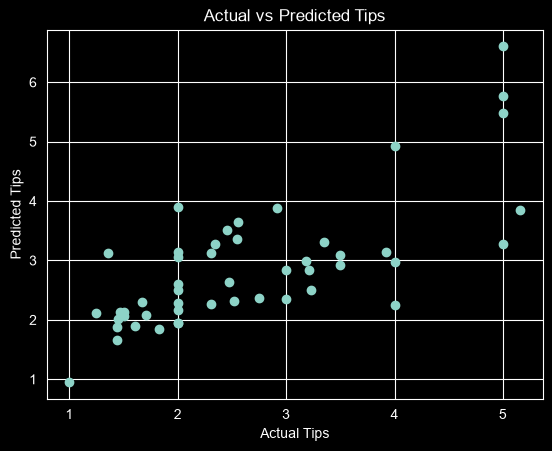

In [27]:
plt.scatter(y_test , y_pred)
plt.xlabel("Actual Tips")
plt.ylabel("Predicted Tips")
plt.title("Actual vs Predicted Tips")
plt.show()